In [40]:
"""
Global binary-hypercube fitness landscape (Q_L) plus M-dimensional sub-landscapes.

Layout: genotypes in columns by Hamming weight (mutations from the all-zero
ancestor); node fill = fitness on a symmetric darkgray->white->orange scale
(white at 0). An adaptive walk (uniform among forward beneficial mutants) is run
from the ancestor to M mutations, resampling the landscape until it succeeds; its
nodes are ringed in salmon and its edges are bolded. First-step selections among
the L single-mutation neighbours are ringed: best M (gold), worst M
(cornflowerblue), random M (lightgray). The closest-fitness distance-M mutant to
the trajectory endpoint is ringed in dimgray.

The composite figure places the global landscape at the centre (panel A) with the
five M-cube sub-landscapes (panels B-F) arranged in a circle around it. Each
sub-cube spans its M loci (letters A..); UPPERCASE = ancestral, lowercase =
derived, with fitness copied from the global landscape.

Requires: networkx, matplotlib, numpy
"""

import os
import itertools
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

In [41]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 8    # Size of the plot title
plt.rcParams['axes.labelsize'] = 8    # Size of x and y labels
plt.rcParams['xtick.labelsize'] = 7   # Size of x-tick labels
plt.rcParams['ytick.labelsize'] = 7   # Size of y-tick labels
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['font.size'] = 8

plt.rcParams.update({
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
    'axes.linewidth': 0.8,
})

In [42]:
cm = 1 / 2.54 

outputdir = '../results/figure1'

# Create the directory
os.makedirs(outputdir, exist_ok=True)

In [43]:
CMAP = LinearSegmentedColormap.from_list("dgwo", ["#404040", "#ffffff", "#e08214"])


# ---------------------------------------------------------------- graph utils
def build_hypercube(L):
    G = nx.Graph()
    nodes = ["".join(bits) for bits in itertools.product("01", repeat=L)]
    for n in nodes:
        G.add_node(n, layer=n.count("1"))
    for u, v in itertools.combinations(nodes, 2):
        if sum(a != b for a, b in zip(u, v)) == 1:
            G.add_edge(u, v)
    return G


def ordered_layers(G, L, sweeps=40):
    layers = {w: sorted([n for n in G if G.nodes[n]["layer"] == w],
                        key=lambda s: int(s, 2)) for w in range(L + 1)}

    def bary(node, ref):
        idx = [ref[nb] for nb in G.neighbors(node) if nb in ref]
        return np.mean(idx) if idx else 0.0

    for it in range(sweeps):
        rng_cols = range(1, L + 1) if it % 2 == 0 else range(L - 1, -1, -1)
        for w in rng_cols:
            adj = w - 1 if it % 2 == 0 else w + 1
            if 0 <= adj <= L:
                ref = {n: i for i, n in enumerate(layers[adj])}
                layers[w].sort(key=lambda n: bary(n, ref))
    return layers

def layered_positions(layers, L, col_gap=1.0, row_gap=1.0, col_row_gap=None):
    col_row_gap = col_row_gap or {}          # {column_index: row_gap for that column}
    pos = {}
    for w in range(L + 1):
        col = layers[w]; n = len(col)
        rg = col_row_gap.get(w, row_gap)     # per-column gap, else the default
        for i, node in enumerate(col):
            pos[node] = (w * col_gap, (i - (n - 1) / 2) * rg)
    return pos


def adaptive_trajectory(G, fitness, L, M, rng):
    current = "0" * L
    traj = [current]
    while current.count("1") < M:
        w = current.count("1")
        fwd = [nb for nb in G.neighbors(current) if nb.count("1") == w + 1]
        beneficial = [nb for nb in fwd if fitness[nb] > fitness[current]]
        if not beneficial:
            return None
        current = beneficial[int(rng.integers(len(beneficial)))]
        traj.append(current)
    return traj


# ---------------------------------------------------------------- compute once
def compute_landscape(L, M, rng, max_tries=100000):
    G = build_hypercube(L)
    layers = ordered_layers(G, L)
    #pos = layered_positions(layers, L)
    pos = layered_positions(layers, L, col_row_gap={1: 2})
    node_list = list(G)

    tries = 0
    while True:
        tries += 1
        fitness = {g: float(rng.standard_normal()) for g in node_list}
        traj = adaptive_trajectory(G, fitness, L, M, rng)
        if traj is not None or tries >= max_tries:
            break
    print(f"[info] adaptive walk reached M={M} after {tries} landscape(s).")

    neighbors = [n for n in node_list if n.count("1") == 1]
    ranked = sorted(neighbors, key=lambda n: fitness[n])
    worst_M, best_M = ranked[:M], ranked[-M:]
    random_M = [str(x) for x in rng.choice(neighbors, size=M, replace=False)]
    endpoint = traj[-1] if traj else "0" * L
    cands = [n for n in node_list if n.count("1") == M and n != endpoint]
    closest = min(cands, key=lambda n: abs(fitness[n] - fitness[endpoint])) \
        if (traj and cands) else None
    if closest:
        print(f"[info] endpoint {endpoint} f={fitness[endpoint]:+.3f}; closest "
              f"{closest} f={fitness[closest]:+.3f} "
              f"(|df|={abs(fitness[closest]-fitness[endpoint]):.3f}).")

    sel = dict(best=best_M, worst=worst_M, random=random_M,
               trajectory=traj, closest=closest)
    vmax = max(abs(v) for v in fitness.values()) or 1.0
    return dict(G=G, layers=layers, pos=pos, fitness=fitness, sel=sel,
                vmax=vmax, node_list=node_list)


# ---------------------------------------------------------------- ring helpers
def ring_definitions(sel, M, size):
    x = .4
    
    return [
        (sel["trajectory"][1:] if sel["trajectory"] else [], "salmon", size*(1.1+2*x), 2.5),
        ([sel["closest"]] if sel["closest"] else [], "dimgray", size*(1.1+3*x), 2.5),
        (sel["best"], "gold", size*(1.1+4*x), 2.5),
        (sel["worst"], "cornflowerblue", size*(1.1+4*x), 2.5),
        (sel["random"], "lightgray", size*(1.1+x), 2.5),
    ]


def ring_legend_handles(M):
    specs = [("salmon", "trajectory"),
             ("dimgray", "conditional"),
             ("gold", "beneficial"),
             ("cornflowerblue", "deleterious"),
             ("lightgray", "random")]
    return [Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="none",
                   markeredgecolor=c, markeredgewidth=2.5, markersize=8, label=l)
            for c, l in specs]


# ---------------------------------------------------------------- draw global
def draw_global(ax, D, L, M, legend=True, compact=False, title=None) :
    
    G, pos, fitness = D["G"], D["pos"], D["fitness"]
    sel, vmax, node_list = D["sel"], D["vmax"], D["node_list"]
    norm = Normalize(vmin=-vmax, vmax=vmax)
    ns = 150 if compact else 850
    BIG = 1.8                       # enlargement factor for circled nodes

    fs = 7 if compact else 11

    # nodes that get a ring in the global landscape (union of all ring groups)
    circled = set()
    for group, color, size, lw in ring_definitions(sel, M, ns):
        circled.update(group)

    size_map = {n: (ns * BIG if n in circled else ns) for n in node_list}

    nx.draw_networkx_edges(G, pos, edge_color="black", width=1.0, alpha=0.2, ax=ax)

    traj = sel["trajectory"]
    if traj and len(traj) > 1:
        tedges = list(zip(traj[:-1], traj[1:]))
        bold = nx.draw_networkx_edges(G, pos, edgelist=tedges, edge_color="salmon",
                                      width=4.0, alpha=0.95, ax=ax)
        if bold is not None:
            bold.set_zorder(1.6)

    vals = np.array([fitness[n] for n in node_list])
    
    nodes = nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_color=vals,
                                   cmap=CMAP, vmin=-vmax, vmax=vmax,
                                   edgecolors="black", linewidths=1.,
                                   node_size=[size_map[n] for n in node_list], ax=ax)
    nodes.set_zorder(2)

    for group, color, size, lw in ring_definitions(sel, M, ns*BIG):
        if group:
            r = nx.draw_networkx_nodes(G, pos, nodelist=list(group),
                                       node_size=size,
                                       node_color="none", edgecolors=color,
                                       linewidths=lw, ax=ax)
            r.set_zorder(3)

    # label only the circled nodes with the derived alleles they carry (lowercase)
    def derived_label(n):
        return "".join(chr(ord("a") + i) for i, c in enumerate(n) if c == "1")

    for n in circled:
        r, g, b = CMAP(norm(fitness[n]))[:3]
        lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        ax.text(*pos[n], derived_label(n), ha="center", va="center",
                fontsize=(7 if compact else 9), family="monospace",
                 color="black" if lum > 0.5 else "white",
                zorder=5)

    
    # letter genotypes under the two endpoints (no numeric in-node labels)
    anc = "".join(chr(ord("A") + i) for i in range(L))
    ax.text(0, -0.9, anc, ha="center", va="top", family="monospace",
            fontsize=fs, fontweight="bold")
    ax.text(L, -0.9, anc.lower(), ha="center", va="top", family="monospace",
            fontsize=fs, fontweight="bold")
    ax.annotate("ancestral", (0, 1.1), ha="center", va="bottom",
                fontsize=fs, color="black")
    ax.annotate("derived", (L, 1.1), ha="center", va="bottom",
                fontsize=fs, color="black")

    ys = [p[1] for p in pos.values()]
    #for w in range(L + 1):
    #    ax.text(w, min(ys) - 1.4, f"{w}", ha="center", va="top",
    #            fontsize=(7 if compact else 9), color="#888")

    
    if legend:
        ax.legend(handles=ring_legend_handles(M) +
                  [Line2D([0], [0], color="salmon", lw=4, label="trajectory edges")],
                  loc="upper left",
                  bbox_to_anchor=(0, 1),
                  bbox_transform=ax.transAxes,
                  frameon=False, fontsize=9, labelspacing=0.2)
             
    if title is None:
        title = f"global landscape$"
    ax.set_title(title, fontsize=(8 if compact else 14), y=.875)
    ax.axis("off"); ax.margins(0.15)
    return nodes

In [44]:
# ---------------------------------------------------------------- composite
def global_mean_by_distance(fitness, L):
    sums = {d: 0.0 for d in range(L + 1)}
    cnts = {d: 0 for d in range(L + 1)}
    for g, f in fitness.items():
        d = g.count("1")
        sums[d] += f
        cnts[d] += 1
    return [sums[d] / cnts[d] for d in range(L + 1)]


def sublib_mean_by_distance(fitness, loci, L, M):
    loci = sorted(loci)
    means = []
    for d in range(M + 1):
        vals = []
        for combo in itertools.combinations(loci, d):
            g = ["0"] * L
            for p in combo:
                g[p] = "1"
            vals.append(fitness["".join(g)])
        means.append(float(np.mean(vals)))
    return means

In [45]:
# ---------------------------------------------------------------- draw subcube
def draw_subcube(ax, loci, D, L, M, color, title):
    fitness, vmax, traj = D["fitness"], D["vmax"], D["sel"]["trajectory"]
    sel = D["sel"]
    loci = sorted(loci)
    letters = [chr(ord("A") + p) for p in loci]
    Gs = build_hypercube(M)
    layers = ordered_layers(Gs, M)
    pos = layered_positions(layers, M, col_gap=0.15, row_gap=0.2)
    norm = Normalize(vmin=-vmax, vmax=vmax)

    k = .9
    node_size=300 * k**2      # area ∝ side², so use k² to shrink linearly
    linewidths=1.0 * k
    
    # rings:
    ring_size=400 * k**2
    ring_linewidths=2.6 * k
    
    # edges:
    edge_width=1.1 * k   #(and 4.0 * k for the bold trajectory)
    
    # labels:
    fontsize=6 * k

    
    def full(sb):
        g = ["0"] * L
        for i, b in enumerate(sb):
            if b == "1":
                g[loci[i]] = "1"
        return "".join(g)

    def lab(sb):
        return "".join(letters[i].lower() if b == "1" else letters[i]
                       for i, b in enumerate(sb))

    def tosub(fg):                       # full L-bit genotype -> sub-cube bits
        return "".join(fg[p] for p in loci)

    subnodes = list(Gs)
    nx.draw_networkx_edges(Gs, pos, edge_color="black", width=edge_width, alpha=0.5, ax=ax)

    if traj:  # bold only if the WHOLE trajectory fits here
        tloci = {i for i, c in enumerate(traj[-1]) if c == "1"}
        if tloci.issubset(set(loci)):
            tedges = [(tosub(a), tosub(b)) for a, b in zip(traj[:-1], traj[1:])]
            bold = nx.draw_networkx_edges(Gs, pos, edgelist=tedges,
                                          edge_color="salmon", width=4.0,
                                          alpha=0.95, ax=ax)
            if bold is not None:
                bold.set_zorder(1.6)

    vals = [fitness[full(s)] for s in subnodes]
    
    
    main = nx.draw_networkx_nodes(Gs, pos, nodelist=subnodes, node_color=vals,
                                  cmap=CMAP, vmin=-vmax, vmax=vmax,
                                  edgecolors="black", linewidths=linewidths,
                                  node_size=node_size, ax=ax)
    main.set_zorder(2)

    # encircle only the mutants that are encircled in the global landscape
    color_groups = {
        "gold":           sel["best"],
        "cornflowerblue": sel["worst"],
        "lightgray":      sel["random"],
        "salmon":         (sel["trajectory"][1:] if sel["trajectory"] else []),
        "dimgray":        ([sel["closest"]] if sel["closest"] else []),
    }
    encircled_full = color_groups.get(color, subnodes)   # fallback: ring all
    ring_nodes = [tosub(fg) for fg in encircled_full
                  if all(fg[p] == "0" for p in range(L) if p not in loci)]

    if ring_nodes:
        ring = nx.draw_networkx_nodes(Gs, pos, nodelist=ring_nodes,
                                      node_color="none", edgecolors=color,
                                      linewidths=ring_linewidths, node_size=ring_size, ax=ax)
        ring.set_zorder(3)

    for s in subnodes:
        r, g, b = CMAP(norm(fitness[full(s)]))[:3]
        lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        ax.text(*pos[s], lab(s), ha="center", va="center", fontsize=6,
                family="monospace", color="black" if lum > 0.5 else "white",
                zorder=4)
    #ax.axis("off"); ax.margins(0.15)

    # replace  ax.axis("off"); ax.margins(0.15)  with:
    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    cx, cy = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2
    xh, yh = (max(xs) - min(xs)) / 2, (max(ys) - min(ys)) / 2
    
    f = 0.5                       # 1.0 = fill (current), 0.5 = occupies half the box
    ax.set_xlim(cx - xh / f, cx + xh / f)
    ax.set_ylim(cy - yh / f, cy + yh / f)

    ax.text(cx, cy + yh + 0.75 * yh, title,
        ha="center", va="bottom",
        transform=ax.transData,
        fontsize=plt.rcParams["axes.titlesize"])

    ax.axis("off")
    return main

In [46]:
def draw_summary_scatter(ax, D, L, M):
    fitness, sel = D["fitness"], D["sel"]

    def w1(n):
        return n.index("1")

    endpoint = sel["trajectory"][-1] if sel["trajectory"] else "0" * L
    libs = [
        ("beneficial",  "gold",           sorted(w1(n) for n in sel["best"])),
        ("deleterious", "cornflowerblue", sorted(w1(n) for n in sel["worst"])),
        ("trajectory",    "salmon",       sorted(i for i, c in enumerate(endpoint) if c == "1")),
        ("random",      "silver",         sorted(w1(n) for n in sel["random"])),
        ("conditional", "dimgray",        sorted(i for i, c in enumerate(sel["closest"]) if c == "1")),
    ]

    ax.axhline(0, color="#ccc", lw=0.8, zorder=0)
    gm = global_mean_by_distance(fitness, L)
    ax.plot(range(L + 1), gm, '-o', color="black", lw=.5, ms=5, label="global", zorder=0)
    for name, color, loci in libs:
        m = sublib_mean_by_distance(fitness, loci, L, M)
        ax.plot(range(M + 1), m, "-o", color=color, lw=.5, ms=5, label=name,
                markeredgecolor="black", markeredgewidth=0.2, zorder=5)

    ax.set_xlabel("dist. from ancestor")
    ax.set_ylabel("average fitness")
    ax.set_title("G", fontweight="bold", loc='left')
    ax.set_xticks(range(L + 1))
    ax.tick_params(labelsize=9)
    #ax.grid(alpha=0.25)
    ax.legend(fontsize=6, frameon=False, ncol=1, bbox_to_anchor=(-.3,.5))

In [47]:
def make_circular_figure(D, L, M, out_path):
    sel, vmax = D["sel"], D["vmax"]
    norm = Normalize(vmin=-vmax, vmax=vmax)

    def w1(n):
        return n.index("1")

    endpoint = sel["trajectory"][-1] if sel["trajectory"] else "0" * L

    wi, hi = .25, .25
    
    # (title, color, loci, axes-rect)  -- placed around an enlarged centre
    panels = [
        (r"$\mathbf{C}$    deleterious",         "cornflowerblue",  sorted(w1(n) for n in sel["worst"]),                         [.03, 0.715, wi, hi]),
        (r"$\mathbf{B}$    beneficial",          "gold",            sorted(w1(n) for n in sel["best"]),                          [0.19, .82, wi, hi]),
        (r"$\mathbf{F}$    conditional",         "dimgray",         sorted(i for i, c in enumerate(sel["closest"]) if c == "1"), [0.72, 0.33, wi, hi]),
        (r"$\mathbf{E}$    random",              "lightgray",       sorted(w1(n) for n in sel["random"]),                        [0.19, 0.33, wi, hi]),
        (r"$\mathbf{D}$    trajectory", "salmon",          sorted(i for i, c in enumerate(endpoint) if c == "1"),       [0.03, 0.465, wi, hi]),
    ]

    fig = plt.figure(figsize=(17*cm, 15*cm))
    center = fig.add_axes([0.2, 0.25, 0.8, .9])
    draw_global(center, D, L, M, legend=False, compact=True,
                title=r"$\mathbf{A}$    global landscape")

    for title, color, loci, rect in panels:
        ax = fig.add_axes(rect)
        letters = [chr(ord("A") + p) for p in loci]
        draw_subcube(ax, loci, D, L, M, color, f"{title}") #\nloci {', '.join(letters)}")

    # right column: legend, colorbar, then the summary scatter
    fig.legend(handles=ring_legend_handles(M), 
               labelspacing=1,#+
               loc="upper right", bbox_to_anchor=(.95, 1.05),
               frameon=False, fontsize=8)
    cbar_ax = fig.add_axes([0.95, 0.62, 0.015, 0.18])
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=norm); sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label="norm. fitness")

    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    print("saved ->", out_path)




[info] adaptive walk reached M=3 after 12 landscape(s).
[info] endpoint 010110 f=+1.429; closest 001011 f=+1.489 (|df|=0.060).
saved -> ../results/figure1/figure_1.png


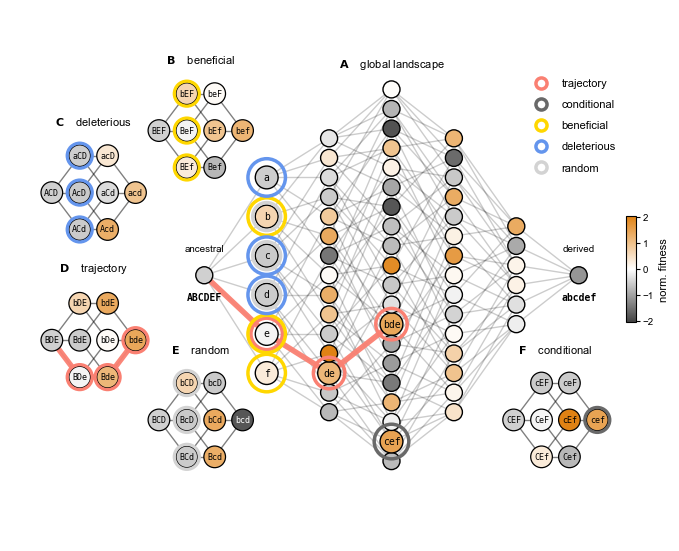

In [48]:
L, M = 6, 3
rng = np.random.default_rng(11)
D = compute_landscape (L, M, rng)

# standalone global landscape
maxcol = max(len(c) for c in D["layers"].values())

# composite: global (A) in the centre, sub-landscapes (B-F) in a circle
make_circular_figure(D, L, M,
                     os.path.join (outputdir, "figure_1.png"))